The Smart Product Recommendation Engine recommends complementary products rather than visually similar products. The system first identifies the category of the selected product and then uses a recommendation knowledge base to determine related categories. Products from these categories are retrieved and displayed as recommendations. This approach mimics real-world e-commerce recommendation systems where customers are shown products that are commonly used together. The system improves user engagement and increases cross-selling opportunities.

In [1]:
!pip install transformers torch torchvision faiss-cpu pandas numpy matplotlib pillow tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 68.6 MB/s eta 0:00:00


In [2]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

In [3]:
styles = pd.read_csv(
    "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/styles.csv",on_bad_lines='skip'
)

styles.head()
print(styles.columns)
print(styles.shape)

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')
(44424, 10)


In [4]:
IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"

valid_rows = []

for _, row in styles.iterrows():

    image_path = os.path.join(
        IMAGE_DIR,
        str(row["id"]) + ".jpg"
    )

    if os.path.exists(image_path):
        valid_rows.append(row)

products_df = pd.DataFrame(valid_rows)

print(products_df.shape)

(44419, 10)


In [5]:
print(products_df.shape)

(44419, 10)


In [6]:
products_df["articleType"].value_counts().head(20)

articleType
Tshirts                  7066
Shirts                   3215
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     608
Name: count, dtype: int64

## Build Recommendation Knowledge Base

In [7]:
recommendation_rules = {

    "Sports Shoes": [
        "Socks",
        "Watches",
        "Track Pants"
    ],

    "Casual Shoes": [
        "Jeans",
        "Tshirts",
        "Belts"
    ],

    "Formal Shoes": [
        "Shirts",
        "Belts",
        "Watches"
    ],

    "Shirts": [
        "Jeans",
        "Belts",
        "Watches"
    ],

    "Jeans": [
        "Tshirts",
        "Casual Shoes",
        "Belts"
    ],

    "Tshirts": [
        "Jeans",
        "Sports Shoes",
        "Watches"
    ]
}

## Recommendation Function

In [8]:
def recommend_products(product_id):

    product = products_df[
        products_df["id"] == product_id
    ].iloc[0]

    article_type = product["articleType"]

    print("Input Product:")
    print(product["productDisplayName"])
    print("Category:", article_type)

    if article_type not in recommendation_rules:
        print("No recommendations available.")
        return []

    recommendations = []

    for target_category in recommendation_rules[article_type]:

        matching = products_df[
            products_df["articleType"] == target_category
        ]

        if len(matching) > 0:
            recommendations.append(
                matching.sample(1)
            )

    return recommendations

## Visualize Recommendations

In [9]:
def show_recommendations(product_id):

    recommendations = recommend_products(product_id)

    if len(recommendations) == 0:
        return

    plt.figure(figsize=(15,5))

    for i, rec in enumerate(recommendations):

        row = rec.iloc[0]

        image_path = os.path.join(
            IMAGE_DIR,
            str(row["id"]) + ".jpg"
        )

        image = Image.open(image_path)

        plt.subplot(
            1,
            len(recommendations),
            i+1
        )

        plt.imshow(image)

        plt.title(
            row["productDisplayName"][:25],
            fontsize=8
        )

        plt.axis("off")

    plt.show()

In [10]:
print(products_df.columns)
print(products_df[["articleType"]].drop_duplicates().head(50))

Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')
               articleType
0                   Shirts
1                    Jeans
2                  Watches
3              Track Pants
4                  Tshirts
8                    Socks
10            Casual Shoes
11                   Belts
12              Flip Flops
13                Handbags
17                    Tops
18                     Bra
21                 Sandals
22        Shoe Accessories
23             Sweatshirts
24               Deodorant
25            Formal Shoes
26                Bracelet
28                Lipstick
34                   Flats
35                  Kurtas
44               Waistcoat
45            Sports Shoes
46                  Shorts
47                  Briefs
60                  Sarees
66   Perfume and Body Mist
76                   Heels
80              Sunglasses
83         Innerwear Vests

## Select a Shoe Product

In [11]:
shoe_products = products_df[
    products_df["articleType"].str.contains(
        "Shoes",
        case=False,
        na=False
    )
]

shoe = shoe_products.iloc[0]

print(shoe["productDisplayName"])
print(shoe["articleType"])

Puma Men Future Cat Remix SF Black Casual Shoes
Casual Shoes


## Run Recommendation Engine

Input Product:
Puma Men Future Cat Remix SF Black Casual Shoes
Category: Casual Shoes


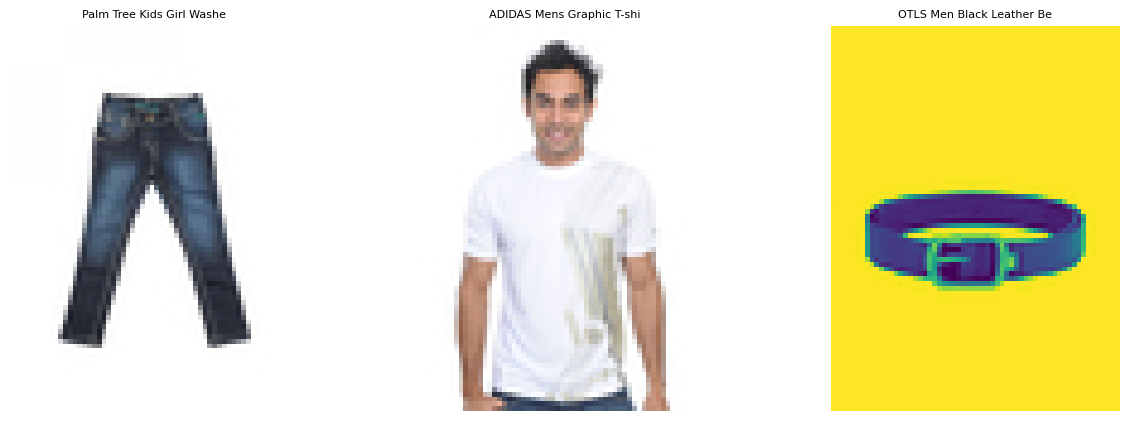

In [12]:
show_recommendations(
    shoe["id"]
)

## Generate Recommendation Explanation

In [13]:
def explain_recommendation(product_id):

    product = products_df[
        products_df["id"] == product_id
    ].iloc[0]

    category = product["articleType"].str.contains(
        "Shoes",
        case=False,
        na=False
    )

    print("Product Category:", category)

    print()

    print("Recommendations generated because customers commonly use these products together.")

    print()

    for item in recommendation_rules.get(category, []):

        print("-", item)